# 1D Black-Scholes Equations Solver Exploration

The goal of this notebook is to provide a preliminary understanding of the problem statement, the object and current existing methods.

## Black-Scholes Setup and Derivation via Portfolio Process

### Assumptions

- The underlying follows geometric Brownian motion: $dS_t = \mu S_t \, dt + \sigma S_t \, dW_t$.
- $\sigma$ and $r$ are constants; markets are frictionless; trading is continuous.
- No-arbitrage holds and borrowing/lending at rate $r$ is allowed.
- European payoff depends only on $S_T$ at maturity $T$.

### Notation and Definitions

- $S_t$ (underlying price): the market price of the base asset (for example, a stock) at time $t$.
- $V(S,t)$ (option value): the fair price of the option when current time is $t$ and current underlying price is $S$.
- $K$ (strike): the pre-agreed exercise price in the option contract.
- $T$ (maturity): the expiration time/date of the option contract.
- $\tau = T-t$ (time-to-maturity): remaining time until expiration.
- $r$ (risk-free rate): continuously compounded interest rate used for discounting under no-arbitrage pricing.
- $\mu$ (drift): expected instantaneous return of the underlying under the physical measure.
- $\sigma$ (volatility): diffusion coefficient controlling uncertainty/randomness in $S_t$.
- $W_t$ (Brownian motion): continuous-time random shock process driving uncertainty.
- $N(\cdot)$: standard normal CDF used in closed-form Black-Scholes pricing.
- $V_t, V_S, V_{SS}$: partial derivatives of $V$ with respect to time and underlying price.
- Terminal condition: the value prescribed at $t=T$ for all $S$, equal to payoff. For a European call: $V(S,T)=\max(S-K,0)$.

In other words:
- Underlying price: the current price of the asset the option is written on.
- Option value: what the option should be worth now, given current market state and model assumptions.
- Strike: the price at which the holder can buy (call) or sell (put) at maturity.
- Maturity: the contract end time when the payoff is realized for European options.
- Terminal condition: the payoff profile used as the boundary at final time when solving backward in time.

Example (European call):
- Suppose $K=100$, $T=1$ year, and at maturity the underlying is $S_T=120$.
- Payoff at maturity is $\max(120-100,0)=20$, so terminal condition gives $V(120,T)=20$.
- If instead $S_T=85$, payoff is $\max(85-100,0)=0$, so $V(85,T)=0$.


### Derivation

Start from Ito's lemma for $V(S_t,t)$:
$$
dV = \underbrace{\left(V_t + \tfrac12 \sigma^2 S^2 V_{SS} + \mu S V_S\right)dt}_{\text{drift}} + \underbrace{\sigma S V_S dW_t}_{\text{diffusion}}.
$$
Define a self-financing hedged portfolio:
$$
\Pi_t = V(S_t,t) - \Delta_t S_t.
$$
Its differential is
$$
d\Pi_t = dV - \Delta_t \, dS_t.
$$
Substitute $dV$ and $dS_t = \mu S_t dt + \sigma S_t dW_t$:
$$
d\Pi_t = \left(V_t + \tfrac12 \sigma^2 S^2 V_{SS} + \mu S V_S\right)dt + \sigma S V_S dW_t - \Delta_t(\mu S dt + \sigma S dW_t).
$$
Collect terms (aligned drift/diffusion):
$$
d\Pi_t = \underbrace{\left(V_t + \tfrac12 \sigma^2 S^2 V_{SS} + \mu S V_S - \Delta_t \mu S\right)dt}_{\text{drift}} + \underbrace{\sigma S (V_S-\Delta_t)dW_t}_{\text{diffusion}}.
$$
Choose $\Delta_t=V_S$ to eliminate diffusion risk. Then
$$
d\Pi_t = \left(V_t + \tfrac12 \sigma^2 S^2 V_{SS}\right)dt.
$$
Because this portfolio is instantaneously riskless, no-arbitrage implies it must earn the risk-free rate:
$$
d\Pi_t = r\Pi_t dt = r\left(V - S V_S\right)dt.
$$
Match drift terms:
$$
V_t + \tfrac12 \sigma^2 S^2 V_{SS} = r(V-SV_S).
$$
Rearrange to get the Black-Scholes PDE:
$$
V_t + \tfrac12 \sigma^2 S^2 V_{SS} + rSV_S - rV = 0.
$$
With terminal condition $V(S,T)=\max(S-K,0)$, the European call solution is:
$$
V(S,t)=S N(d_1) - K e^{-r(T-t)} N(d_2),
$$
$$
d_1 = \frac{\ln(S/K)+(r+\tfrac12 \sigma^2)(T-t)}{\sigma\sqrt{T-t}}, \quad d_2=d_1-\sigma\sqrt{T-t}.
$$


## Interactive 3D Render
Use this Plotly figure to zoom, pan, and rotate the BS surface interactively.

In [1]:
# Interactive Black-Scholes 3D surface with Plotly
import numpy as np
from scipy.stats import norm
import plotly.graph_objects as go

K = 1000.0
r = 0.05
sigma = 0.2
T = 100.0
S_max = 220.0

S = np.linspace(1e-6, S_max, 160)
t = np.linspace(0.0, T, 140)
S_grid, t_grid = np.meshgrid(S, t)
tau = T - t_grid

sqrt_tau = np.sqrt(np.maximum(tau, 1e-12))
d1 = (np.log(S_grid / K) + (r + 0.5 * sigma**2) * tau) / (sigma * sqrt_tau)
d2 = d1 - sigma * sqrt_tau
V = S_grid * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)
payoff = np.maximum(S - K, 0.0)
V[-1, :] = payoff

fig = go.Figure()
fig.add_trace(go.Surface(x=S_grid, y=t_grid, z=V, colorscale='Viridis', opacity=0.92, colorbar=dict(title='V(S,t)'), name='PDE interior'))

# Red boundary lines: t=0, t=T, S=0, S=Smax
fig.add_trace(go.Scatter3d(x=S, y=np.zeros_like(S), z=V[0, :], mode='lines', line=dict(color='red', width=7), name='Boundary: t=0'))
fig.add_trace(go.Scatter3d(x=S, y=np.full_like(S, T), z=V[-1, :], mode='lines', line=dict(color='red', width=8), name='Boundary: t=T (terminal)'))
fig.add_trace(go.Scatter3d(x=np.full_like(t, S[0]), y=t, z=V[:, 0], mode='lines', line=dict(color='red', width=7), name='Boundary: S=0'))
fig.add_trace(go.Scatter3d(x=np.full_like(t, S_max), y=t, z=V[:, -1], mode='lines', line=dict(color='red', width=7), name='Boundary: S=Smax'))

s_pad = 0.05 * S_max
v_min, v_max = float(np.min(V)), float(np.max(V))
v_pad = 0.08 * (v_max - v_min + 1e-12)

fig.update_layout(
    title='Interactive European Call Surface V(S,t) under Black-Scholes',
    scene=dict(
        xaxis_title='Underlying price S',
        yaxis_title='Time t',
        zaxis_title='Option value V',
        xaxis=dict(range=[-s_pad, S_max + s_pad]),
        yaxis=dict(range=[-0.05 * T, T + 0.05 * T]),
        zaxis=dict(range=[v_min - v_pad, v_max + v_pad]),
    ),
    width=950,
    height=700,
    margin=dict(l=0, r=0, b=0, t=50),
)
fig.show()


## Analytic Solution vs Surface Approximation, and Truncation in Practice

The Black-Scholes PDE defines a function $V(S,t)$ with terminal and boundary conditions.

- Analytic approach: derive a closed-form expression for $V(S,t)$ (for vanilla European options).
- Numerical approach: approximate the same function on a discrete/computational domain.

So both approaches target the same object: the option-value surface over $(S,t)$. The difference is representation:
- closed-form formula (exact within model assumptions), versus
- discrete/parametric approximation (controlled numerical error).



### Truncation

The natural domain is semi-infinite in price: $S\in(0,\infty)$. Computation requires finite resources, so methods either:
- truncate to $S\in[0,S_{\max}]$, or
- transform/map variables so computation still occurs on a finite effective domain.

Truncation introduces boundary and domain-truncation error, which is controlled by choosing $S_{\max}$ large enough and checking convergence.

**Finite Difference (FD)**
- Uses a grid on $[0,S_{\max}]\times[0,T]$.
- Imposes boundary conditions at $S=0$ and $S=S_{\max}$ (e.g., call: $V(0,t)=0$, $V(S_{\max},t)\approx S_{\max}-Ke^{-r(T-t)}$).
- Truncation is explicit; verify by increasing $S_{\max}$ and refining mesh.

**Finite Element (FE)**
- Formulates weak form on a bounded interval in $S$ (or transformed variable).
- Boundary conditions enforced strongly/weakly depending on formulation.
- Same truncation logic as FD: finite computational domain + convergence checks.

**Fourier-family methods (FFT/COS/transform-based pricing)**
- Often move to log-price and characteristic-function space.
- In practice still use finite integration window / finite series truncation.
- Error control comes from damping, window size, and number of modes/terms.

**PINNs (Physics-Informed Neural Networks)**
- Train a neural network surrogate $V_\theta(S,t)$ on sampled collocation points.
- Usually train on bounded domain $[0,S_{\max}]\times[0,T]$ with PDE residual + boundary/terminal losses.
- Truncation appears via sampled domain and boundary design; robustness requires good sampling near boundaries and validation against larger $S_{\max}$.

Regardless of method, treat truncation as a modeling hyperparameter:
1. Pick conservative $S_{\max}$ from volatility/time-to-maturity heuristics.
2. Re-solve with larger $S_{\max}$ and compare price/Greeks at points of interest.
3. Accept when changes are below tolerance.


## Finite Difference (FD) Baseline and Experiment Setup

### Core FD idea

We solve the Black-Scholes PDE backward in time on a truncated rectangle $S\in[0,S_{\max}]$, $t\in[0,T]$.

- Discretize price with grid points $S_i=i\,\Delta S$ and time with $t_n=n\,\Delta t$.
- Use terminal condition at maturity: $V(S,T)=\max(S-K,0)$.
- Use boundary conditions (call): $V(0,t)=0$, $V(S_{\max},t)\approx S_{\max}-Ke^{-r(T-t)}$.
- March backward from $t=T$ to $t=0$ using a stable scheme (Crank-Nicolson).

### Setup for later experiments

This FD solver will be the baseline for comparing FE, Fourier-family methods, and PINN later.

For fair comparisons, keep the same model parameters and report:
1. Accuracy vs closed form (MSE over $S$ at each time).
2. Convergence vs grid/domain choices ($\Delta S,\Delta t,S_{\max}$).
3. Runtime/cost for a target error level.

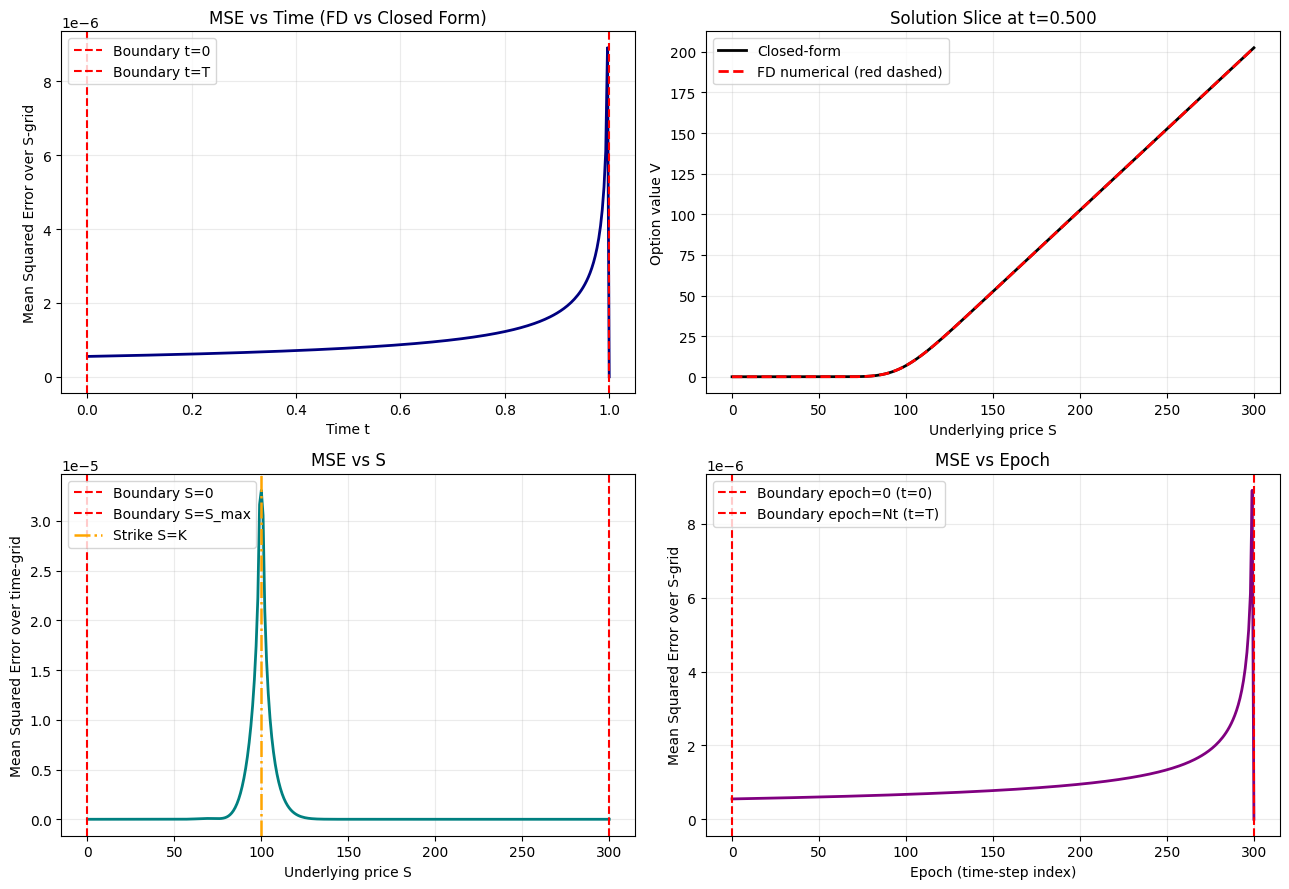

Max MSE over time: 8.9109e-06
MSE at t=0: 5.5085e-07


In [2]:
# FD (Crank-Nicolson) baseline for Black-Scholes call + error diagnostics
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters
K = 100.0
r = 0.05
sigma = 0.2
T = 1.0
S_max = 300.0
Ns = 300   # S steps
Nt = 300   # time steps

S = np.linspace(0.0, S_max, Ns + 1)
t = np.linspace(0.0, T, Nt + 1)
dS = S[1] - S[0]
dt = t[1] - t[0]

# Storage: V[n, i] ~ V(S_i, t_n)
V = np.zeros((Nt + 1, Ns + 1), dtype=float)

# Terminal condition at t=T
V[-1, :] = np.maximum(S - K, 0.0)

# Boundary conditions for all times
V[:, 0] = 0.0
V[:, -1] = S_max - K * np.exp(-r * (T - t))

# Build tridiagonal operators on interior nodes i=1..Ns-1
i = np.arange(1, Ns)
a = 0.5 * sigma**2 * i**2 - 0.5 * r * i
b = -(sigma**2 * i**2 + r)
c = 0.5 * sigma**2 * i**2 + 0.5 * r * i

# A corresponds to dV/dt = A V (on interior)
A_sub = a
A_diag = b
A_sup = c

# CN matrices: (I - 0.5 dt A) V^n = (I + 0.5 dt A) V^{n+1}
L_sub = -0.5 * dt * A_sub[1:]
L_diag = 1.0 - 0.5 * dt * A_diag
L_sup = -0.5 * dt * A_sup[:-1]

R_sub = 0.5 * dt * A_sub[1:]
R_diag = 1.0 + 0.5 * dt * A_diag
R_sup = 0.5 * dt * A_sup[:-1]

def tridiag_mv(sub, diag, sup, x):
    y = diag * x
    y[1:] += sub * x[:-1]
    y[:-1] += sup * x[1:]
    return y

def solve_tridiag(sub, diag, sup, rhs):
    # Thomas algorithm
    n = len(diag)
    c = np.zeros(n - 1)
    d = np.zeros(n)
    c[0] = sup[0] / diag[0]
    d[0] = rhs[0] / diag[0]
    for k in range(1, n - 1):
        den = diag[k] - sub[k - 1] * c[k - 1]
        c[k] = sup[k] / den
        d[k] = (rhs[k] - sub[k - 1] * d[k - 1]) / den
    d[-1] = (rhs[-1] - sub[-1] * d[-2]) / (diag[-1] - sub[-1] * c[-1])
    x = np.zeros(n)
    x[-1] = d[-1]
    for k in range(n - 2, -1, -1):
        x[k] = d[k] - c[k] * x[k + 1]
    return x

# Backward time stepping: n = Nt-1, ..., 0
for n in range(Nt - 1, -1, -1):
    v_next = V[n + 1, 1:-1]
    rhs = tridiag_mv(R_sub, R_diag, R_sup, v_next)

    # Boundary contributions
    rhs[0] += 0.5 * dt * A_sub[0] * (V[n + 1, 0] + V[n, 0])
    rhs[-1] += 0.5 * dt * A_sup[-1] * (V[n + 1, -1] + V[n, -1])

    V[n, 1:-1] = solve_tridiag(L_sub, L_diag, L_sup, rhs)

# Closed-form BS call for comparison
def bs_call(Sv, tv, K, r, sigma, T):
    tau = T - tv
    Sv = np.asarray(Sv, dtype=float)
    out = np.maximum(Sv - K, 0.0)
    mask = tau > 1e-12
    if np.isscalar(tv):
        if mask:
            s = np.maximum(Sv, 1e-300)
            st = np.sqrt(tau)
            d1 = (np.log(s / K) + (r + 0.5 * sigma**2) * tau) / (sigma * st)
            d2 = d1 - sigma * st
            out = s * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)
        return out
    raise ValueError('tv should be scalar in this helper')

V_exact = np.zeros_like(V)
for n in range(Nt + 1):
    V_exact[n, :] = bs_call(S, t[n], K, r, sigma, T)

sq_err = (V - V_exact) ** 2
mse_t = np.mean(sq_err, axis=1)              # MSE vs time
mse_s = np.mean(sq_err, axis=0)              # MSE vs S
epoch = np.arange(Nt + 1)                    # epoch index (time-slice index)
mse_epoch = mse_t.copy()                     # same values, indexed by epoch

# A representative time-slice comparison
n_mid = Nt // 2

fig, ax = plt.subplots(2, 2, figsize=(13, 9))

ax[0, 0].plot(t, mse_t, color='navy', lw=2)
ax[0, 0].set_title('MSE vs Time (FD vs Closed Form)')
ax[0, 0].set_xlabel('Time t')
ax[0, 0].set_ylabel('Mean Squared Error over S-grid')
ax[0, 0].axvline(0.0, color='red', ls='--', lw=1.5, label='Boundary t=0')
ax[0, 0].axvline(T, color='red', ls='--', lw=1.5, label='Boundary t=T')
ax[0, 0].legend(loc='upper left')
ax[0, 0].grid(alpha=0.25)

ax[0, 1].plot(S, V_exact[n_mid, :], color='black', lw=2, label='Closed-form')
ax[0, 1].plot(S, V[n_mid, :], 'r--', lw=2, label='FD numerical (red dashed)')
ax[0, 1].set_title(f'Solution Slice at t={t[n_mid]:.3f}')
ax[0, 1].set_xlabel('Underlying price S')
ax[0, 1].set_ylabel('Option value V')
ax[0, 1].legend()
ax[0, 1].grid(alpha=0.25)

ax[1, 0].plot(S, mse_s, color='teal', lw=2)
ax[1, 0].set_title('MSE vs S')
ax[1, 0].set_xlabel('Underlying price S')
ax[1, 0].set_ylabel('Mean Squared Error over time-grid')
ax[1, 0].axvline(0.0, color='red', ls='--', lw=1.5, label='Boundary S=0')
ax[1, 0].axvline(S_max, color='red', ls='--', lw=1.5, label='Boundary S=S_max')
ax[1, 0].axvline(K, color='orange', ls='-.', lw=1.8, label='Strike S=K')
ax[1, 0].legend(loc='upper left')
ax[1, 0].grid(alpha=0.25)

ax[1, 1].plot(epoch, mse_epoch, color='purple', lw=2)
ax[1, 1].set_title('MSE vs Epoch')
ax[1, 1].set_xlabel('Epoch (time-step index)')
ax[1, 1].set_ylabel('Mean Squared Error over S-grid')
ax[1, 1].axvline(0, color='red', ls='--', lw=1.5, label='Boundary epoch=0 (t=0)')
ax[1, 1].axvline(Nt, color='red', ls='--', lw=1.5, label='Boundary epoch=Nt (t=T)')
ax[1, 1].legend(loc='upper left')
ax[1, 1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f'Max MSE over time: {mse_t.max():.4e}')
print(f'MSE at t=0: {mse_t[0]:.4e}')


This interactive view overlays Black-Scholes closed-form (ground truth) and FD approximation.

In [3]:
# Interactive 3D overlay: closed-form surface vs FD surface
import numpy as np
from scipy.stats import norm
import plotly.graph_objects as go

# Reuse FD outputs if present; otherwise compute quickly
need_recompute = any(name not in globals() for name in ['S', 't', 'V', 'V_exact', 'K', 'r', 'sigma', 'T'])

if need_recompute:
    K = 100.0
    r = 0.05
    sigma = 0.2
    T = 1.0
    S_max = 300.0
    Ns = 300
    Nt = 300

    S = np.linspace(0.0, S_max, Ns + 1)
    t = np.linspace(0.0, T, Nt + 1)
    dt = t[1] - t[0]

    V = np.zeros((Nt + 1, Ns + 1), dtype=float)
    V[-1, :] = np.maximum(S - K, 0.0)
    V[:, 0] = 0.0
    V[:, -1] = S_max - K * np.exp(-r * (T - t))

    i = np.arange(1, Ns)
    a = 0.5 * sigma**2 * i**2 - 0.5 * r * i
    b = -(sigma**2 * i**2 + r)
    c = 0.5 * sigma**2 * i**2 + 0.5 * r * i

    A_sub, A_diag, A_sup = a, b, c
    L_sub = -0.5 * dt * A_sub[1:]
    L_diag = 1.0 - 0.5 * dt * A_diag
    L_sup = -0.5 * dt * A_sup[:-1]
    R_sub = 0.5 * dt * A_sub[1:]
    R_diag = 1.0 + 0.5 * dt * A_diag
    R_sup = 0.5 * dt * A_sup[:-1]

    def tridiag_mv(sub, diag, sup, x):
        y = diag * x
        y[1:] += sub * x[:-1]
        y[:-1] += sup * x[1:]
        return y

    def solve_tridiag(sub, diag, sup, rhs):
        n = len(diag)
        cp = np.zeros(n - 1)
        dp = np.zeros(n)
        cp[0] = sup[0] / diag[0]
        dp[0] = rhs[0] / diag[0]
        for k in range(1, n - 1):
            den = diag[k] - sub[k - 1] * cp[k - 1]
            cp[k] = sup[k] / den
            dp[k] = (rhs[k] - sub[k - 1] * dp[k - 1]) / den
        dp[-1] = (rhs[-1] - sub[-1] * dp[-2]) / (diag[-1] - sub[-1] * cp[-1])
        x = np.zeros(n)
        x[-1] = dp[-1]
        for k in range(n - 2, -1, -1):
            x[k] = dp[k] - cp[k] * x[k + 1]
        return x

    for n in range(Nt - 1, -1, -1):
        v_next = V[n + 1, 1:-1]
        rhs = tridiag_mv(R_sub, R_diag, R_sup, v_next)
        rhs[0] += 0.5 * dt * A_sub[0] * (V[n + 1, 0] + V[n, 0])
        rhs[-1] += 0.5 * dt * A_sup[-1] * (V[n + 1, -1] + V[n, -1])
        V[n, 1:-1] = solve_tridiag(L_sub, L_diag, L_sup, rhs)

    def bs_call(Sv, tv):
        tau = T - tv
        Sv = np.asarray(Sv, dtype=float)
        if tau <= 1e-12:
            return np.maximum(Sv - K, 0.0)
        s = np.maximum(Sv, 1e-300)
        st = np.sqrt(tau)
        d1 = (np.log(s / K) + (r + 0.5 * sigma**2) * tau) / (sigma * st)
        d2 = d1 - sigma * st
        return s * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)

    V_exact = np.zeros_like(V)
    for n in range(Nt + 1):
        V_exact[n, :] = bs_call(S, t[n])

# Subsample for smoother interactive rendering
s_step = max(1, len(S) // 120)
t_step = max(1, len(t) // 120)
S_sub = S[::s_step]
t_sub = t[::t_step]
V_fd_sub = V[::t_step, ::s_step]
V_gt_sub = V_exact[::t_step, ::s_step]
Sg, tg = np.meshgrid(S_sub, t_sub)

fig = go.Figure()

fig.add_trace(go.Surface(
    x=Sg, y=tg, z=V_gt_sub,
    colorscale='Blues', opacity=0.85,
    name='Ground truth (closed-form)',
    showscale=False
))

fig.add_trace(go.Surface(
    x=Sg, y=tg, z=V_fd_sub,
    colorscale='Reds', opacity=0.45,
    name='FD approximation',
    showscale=False
))

# Add an error magnitude colorbar via a thin helper surface (hidden geometry)
err = np.abs(V_fd_sub - V_gt_sub)
fig.add_trace(go.Surface(
    x=Sg, y=tg, z=V_gt_sub*0 + np.nan,
    surfacecolor=err, colorscale='Viridis', showscale=True,
    colorbar=dict(title='|FD - GT|'),
    hoverinfo='skip',
    name='Absolute error scale'
))

fig.update_layout(
    title='3D Overlay: Ground Truth vs FD Approximation',
    scene=dict(
        xaxis_title='Underlying price S',
        yaxis_title='Time t',
        zaxis_title='Option value V'
    ),
    width=980, height=760,
    margin=dict(l=0, r=0, b=0, t=45)
)

fig.show()


## Finite Element (FE) Baseline and Experiment Setup

### Core FE idea

We solve the same Black-Scholes PDE on $S\in[0,S_{\max}]$, $t\in[0,T]$ using a Galerkin finite-element discretization in space and Crank-Nicolson in time.

- Build linear (P1) basis functions on a 1D mesh in $S$.
- Assemble mass matrix $M$ and spatial operator from weak form terms.
- Enforce call boundary conditions at $S=0$ and $S=S_{\max}$.
- March backward from $t=T$ to $t=0$ like in FD.

### Setup for comparison with FD

Use the same parameters and evaluation protocol so FE vs FD is comparable:
1. MSE vs time against Black-Scholes closed form.
2. MSE vs $S$ and vs epoch (time-slice index).
3. Mid-time slice comparison against closed form.

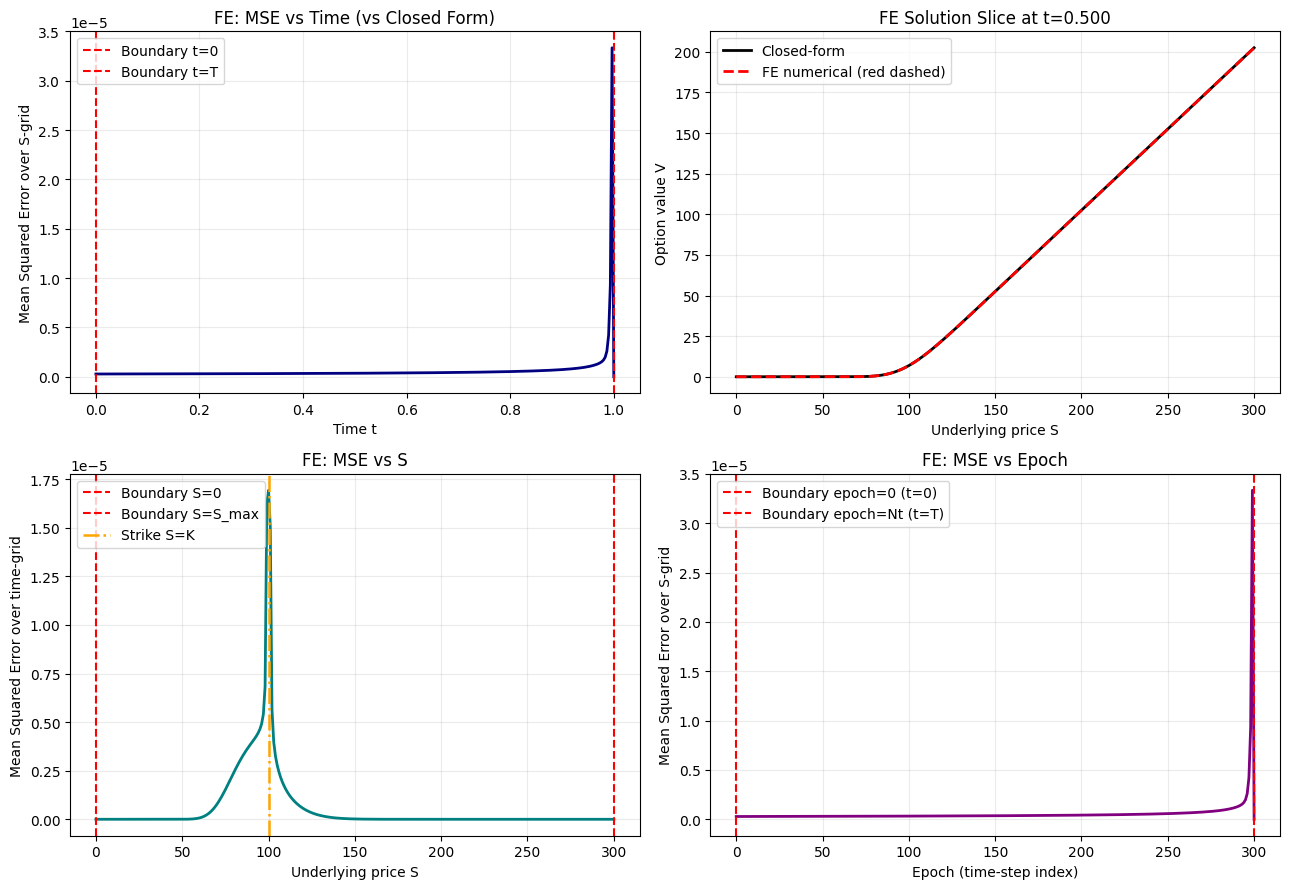

FE max MSE over time: 3.3347e-05
FE MSE at t=0: 2.8133e-07


In [4]:
# FE (P1 Galerkin + Crank-Nicolson) baseline for Black-Scholes call
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters (aligned with FD section)
K = 100.0
r = 0.05
sigma = 0.2
T = 1.0
S_max = 300.0
Ns = 300
Nt = 300
theta = 0.5  # Crank-Nicolson

S = np.linspace(0.0, S_max, Ns + 1)
t = np.linspace(0.0, T, Nt + 1)
dt = t[1] - t[0]

# FE solution storage: V_fe[n, i] ~ V(S_i, t_n)
V_fe = np.zeros((Nt + 1, Ns + 1), dtype=float)

# Terminal condition and boundaries
V_fe[-1, :] = np.maximum(S - K, 0.0)
V_fe[:, 0] = 0.0
V_fe[:, -1] = S_max - K * np.exp(-r * (T - t))

# Assemble FE matrices: M and H where M dV/dt = H V
n_nodes = Ns + 1
M = np.zeros((n_nodes, n_nodes), dtype=float)
K1 = np.zeros((n_nodes, n_nodes), dtype=float)
G = np.zeros((n_nodes, n_nodes), dtype=float)

for e in range(Ns):
    i0, i1 = e, e + 1
    x0, x1 = S[i0], S[i1]
    h = x1 - x0
    xm = 0.5 * (x0 + x1)

    # Coefficients at element midpoint
    a = 0.5 * sigma**2 * xm**2
    c = (r - sigma**2) * xm   # from weak form after integration by parts

    Mloc = (h / 6.0) * np.array([[2.0, 1.0], [1.0, 2.0]])
    Kloc = (a / h) * np.array([[1.0, -1.0], [-1.0, 1.0]])
    Gloc = c * np.array([[-0.5, 0.5], [-0.5, 0.5]])

    idx = [i0, i1]
    for A in range(2):
        for B in range(2):
            M[idx[A], idx[B]] += Mloc[A, B]
            K1[idx[A], idx[B]] += Kloc[A, B]
            G[idx[A], idx[B]] += Gloc[A, B]

H = K1 - G + r * M

# Time stepping system: (M + theta*dt*H)V^n = (M - (1-theta)*dt*H)V^{n+1}
L = M + theta * dt * H
R = M - (1.0 - theta) * dt * H

# Interior system with Dirichlet boundaries
I = slice(1, Ns)
L_II = L[I, I]
R_II = R[I, I]
L_Ib = np.column_stack([L[I, 0], L[I, -1]])
R_Ib = np.column_stack([R[I, 0], R[I, -1]])

for n in range(Nt - 1, -1, -1):
    u_next = V_fe[n + 1, 1:-1]
    g_n = np.array([V_fe[n, 0], V_fe[n, -1]])
    g_np1 = np.array([V_fe[n + 1, 0], V_fe[n + 1, -1]])

    rhs = R_II @ u_next + R_Ib @ g_np1 - L_Ib @ g_n
    V_fe[n, 1:-1] = np.linalg.solve(L_II, rhs)

# Closed-form BS call for reference
def bs_call(Sv, tv, K, r, sigma, T):
    tau = T - tv
    Sv = np.asarray(Sv, dtype=float)
    if tau <= 1e-12:
        return np.maximum(Sv - K, 0.0)
    s = np.maximum(Sv, 1e-300)
    st = np.sqrt(tau)
    d1 = (np.log(s / K) + (r + 0.5 * sigma**2) * tau) / (sigma * st)
    d2 = d1 - sigma * st
    return s * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)

V_exact_fe = np.zeros_like(V_fe)
for n in range(Nt + 1):
    V_exact_fe[n, :] = bs_call(S, t[n], K, r, sigma, T)

sq_err = (V_fe - V_exact_fe) ** 2
mse_t = np.mean(sq_err, axis=1)
mse_s = np.mean(sq_err, axis=0)
epoch = np.arange(Nt + 1)
mse_epoch = mse_t.copy()

n_mid = Nt // 2

fig, ax = plt.subplots(2, 2, figsize=(13, 9))

ax[0, 0].plot(t, mse_t, color='navy', lw=2)
ax[0, 0].set_title('FE: MSE vs Time (vs Closed Form)')
ax[0, 0].set_xlabel('Time t')
ax[0, 0].set_ylabel('Mean Squared Error over S-grid')
ax[0, 0].axvline(0.0, color='red', ls='--', lw=1.5, label='Boundary t=0')
ax[0, 0].axvline(T, color='red', ls='--', lw=1.5, label='Boundary t=T')
ax[0, 0].legend(loc='upper left')
ax[0, 0].grid(alpha=0.25)

ax[0, 1].plot(S, V_exact_fe[n_mid, :], color='black', lw=2, label='Closed-form')
ax[0, 1].plot(S, V_fe[n_mid, :], 'r--', lw=2, label='FE numerical (red dashed)')
ax[0, 1].set_title(f'FE Solution Slice at t={t[n_mid]:.3f}')
ax[0, 1].set_xlabel('Underlying price S')
ax[0, 1].set_ylabel('Option value V')
ax[0, 1].legend()
ax[0, 1].grid(alpha=0.25)

ax[1, 0].plot(S, mse_s, color='teal', lw=2)
ax[1, 0].set_title('FE: MSE vs S')
ax[1, 0].set_xlabel('Underlying price S')
ax[1, 0].set_ylabel('Mean Squared Error over time-grid')
ax[1, 0].axvline(0.0, color='red', ls='--', lw=1.5, label='Boundary S=0')
ax[1, 0].axvline(S_max, color='red', ls='--', lw=1.5, label='Boundary S=S_max')
ax[1, 0].axvline(K, color='orange', ls='-.', lw=1.8, label='Strike S=K')
ax[1, 0].legend(loc='upper left')
ax[1, 0].grid(alpha=0.25)

ax[1, 1].plot(epoch, mse_epoch, color='purple', lw=2)
ax[1, 1].set_title('FE: MSE vs Epoch')
ax[1, 1].set_xlabel('Epoch (time-step index)')
ax[1, 1].set_ylabel('Mean Squared Error over S-grid')
ax[1, 1].axvline(0, color='red', ls='--', lw=1.5, label='Boundary epoch=0 (t=0)')
ax[1, 1].axvline(Nt, color='red', ls='--', lw=1.5, label='Boundary epoch=Nt (t=T)')
ax[1, 1].legend(loc='upper left')
ax[1, 1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f'FE max MSE over time: {mse_t.max():.4e}')
print(f'FE MSE at t=0: {mse_t[0]:.4e}')


## Fourier Method Baseline and Experiment Setup

### Core Fourier idea

Use a Fourier-family COS expansion for the Black-Scholes pricing integral at each time slice.

- Expand the risk-neutral density/payoff projection in cosine basis on a truncated log-price interval.
- Evaluate option values across the $S$ grid for each $t$ (equivalently each $\tau=T-t$).
- Truncation appears through finite log-price interval and finite number of cosine modes.

### Setup for comparison

As with FD/FE, compare to closed form using:
1. MSE vs time
2. MSE vs $S$ and vs epoch (time-slice index)
3. Mid-time solution slice with red dashed numerical curve

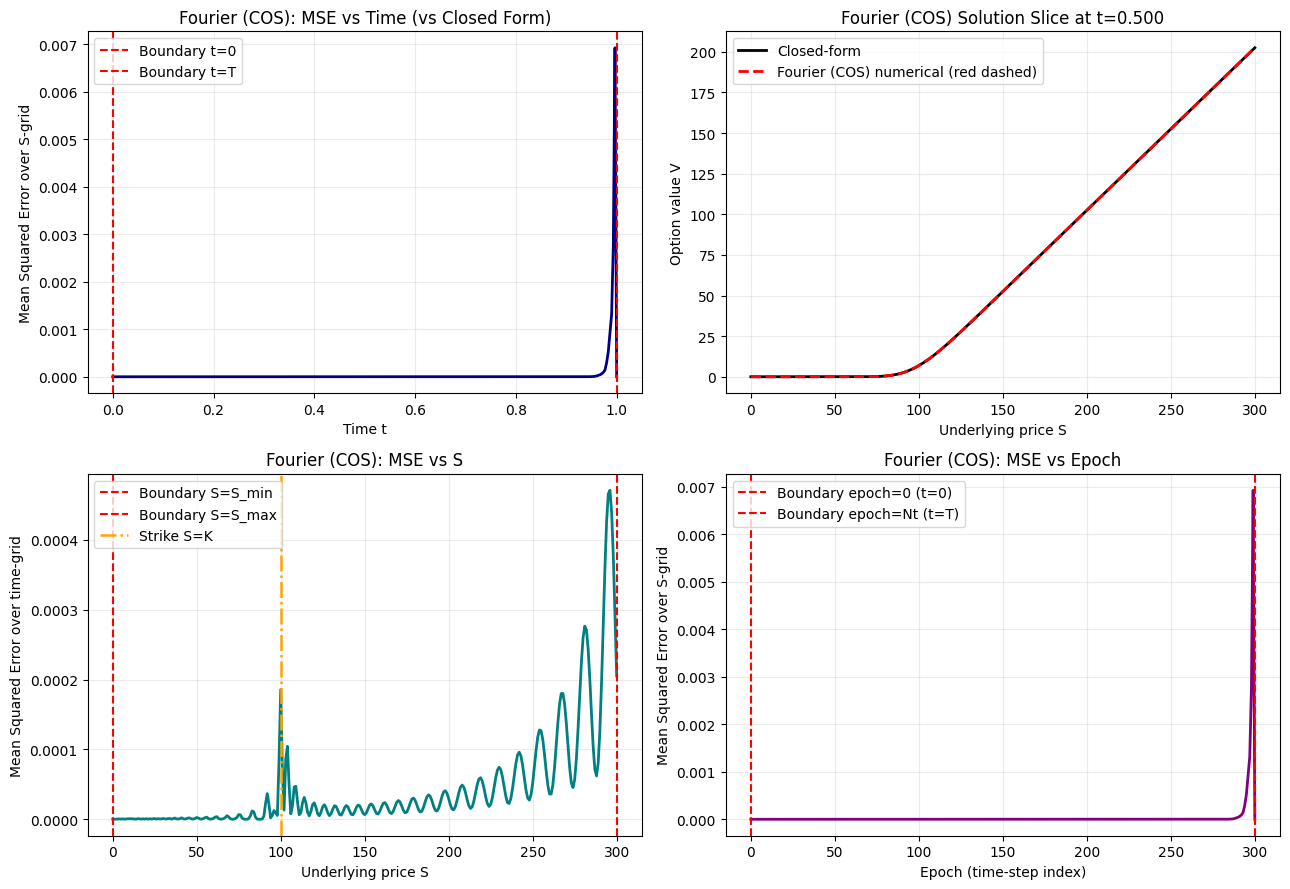

Fourier (COS) max MSE over time: 6.9286e-03
Fourier (COS) MSE at t=0: 9.5712e-25


In [5]:
# Fourier-family baseline (COS method) for Black-Scholes call
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters
K = 100.0
r = 0.05
sigma = 0.2
T = 1.0
S_min = 1e-3
S_max = 300.0
Ns = 300
Nt = 300
Ncos = 256
L = 10.0

S = np.linspace(S_min, S_max, Ns + 1)
x = np.log(S / K)
t = np.linspace(0.0, T, Nt + 1)

def bs_call(Sv, tv, K, r, sigma, T):
    tau = T - tv
    Sv = np.asarray(Sv, dtype=float)
    if tau <= 1e-12:
        return np.maximum(Sv - K, 0.0)
    s = np.maximum(Sv, 1e-300)
    st = np.sqrt(tau)
    d1 = (np.log(s / K) + (r + 0.5 * sigma**2) * tau) / (sigma * st)
    d2 = d1 - sigma * st
    return s * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)

def cos_payoff_coeff_call(a, b, K, N):
    k = np.arange(N, dtype=float)
    u = k * np.pi / (b - a)

    c = max(0.0, a)
    d = b
    if d <= c:
        return np.zeros(N), u

    exp_c = np.exp(c)
    exp_d = np.exp(d)

    cos_dc = np.cos(u * (d - a))
    cos_cc = np.cos(u * (c - a))
    sin_dc = np.sin(u * (d - a))
    sin_cc = np.sin(u * (c - a))

    chi = (exp_d * (cos_dc + u * sin_dc) - exp_c * (cos_cc + u * sin_cc)) / (1.0 + u**2)

    psi = np.zeros_like(u)
    psi[0] = d - c
    psi[1:] = (sin_dc[1:] - sin_cc[1:]) / u[1:]

    Vk = 2.0 / (b - a) * K * (chi - psi)
    return Vk, u

def cos_call_prices(S, tau, K, r, sigma, N=256, L=10.0):
    if tau <= 1e-12:
        return np.maximum(S - K, 0.0)

    x = np.log(np.maximum(S, 1e-300) / K)
    x_min, x_max = float(np.min(x)), float(np.max(x))

    # Global truncation interval for y=ln(S_T/K) covering all current x values
    m_min = x_min + (r - 0.5 * sigma**2) * tau
    m_max = x_max + (r - 0.5 * sigma**2) * tau
    s = sigma * np.sqrt(tau)
    a = m_min - L * s
    b = m_max + L * s

    Vk, u = cos_payoff_coeff_call(a, b, K, N)
    Vk[0] *= 0.5  # prime-sum adjustment

    iu = 1j * u[None, :]
    phi = np.exp(iu * (x[:, None] + (r - 0.5 * sigma**2) * tau) - 0.5 * sigma**2 * (u[None, :]**2) * tau)
    Fk = np.real(phi * np.exp(-1j * u[None, :] * a))
    prices = np.exp(-r * tau) * (Fk @ Vk)
    return np.maximum(prices, 0.0)

V_fourier = np.zeros((Nt + 1, Ns + 1), dtype=float)
for n in range(Nt + 1):
    tau = T - t[n]
    V_fourier[n, :] = cos_call_prices(S, tau, K, r, sigma, N=Ncos, L=L)

V_exact_fourier = np.zeros_like(V_fourier)
for n in range(Nt + 1):
    V_exact_fourier[n, :] = bs_call(S, t[n], K, r, sigma, T)

sq_err = (V_fourier - V_exact_fourier) ** 2
mse_t = np.mean(sq_err, axis=1)
mse_s = np.mean(sq_err, axis=0)
epoch = np.arange(Nt + 1)
mse_epoch = mse_t.copy()

n_mid = Nt // 2

fig, ax = plt.subplots(2, 2, figsize=(13, 9))

ax[0, 0].plot(t, mse_t, color='navy', lw=2)
ax[0, 0].set_title('Fourier (COS): MSE vs Time (vs Closed Form)')
ax[0, 0].set_xlabel('Time t')
ax[0, 0].set_ylabel('Mean Squared Error over S-grid')
ax[0, 0].axvline(0.0, color='red', ls='--', lw=1.5, label='Boundary t=0')
ax[0, 0].axvline(T, color='red', ls='--', lw=1.5, label='Boundary t=T')
ax[0, 0].legend(loc='upper left')
ax[0, 0].grid(alpha=0.25)

ax[0, 1].plot(S, V_exact_fourier[n_mid, :], color='black', lw=2, label='Closed-form')
ax[0, 1].plot(S, V_fourier[n_mid, :], 'r--', lw=2, label='Fourier (COS) numerical (red dashed)')
ax[0, 1].set_title(f'Fourier (COS) Solution Slice at t={t[n_mid]:.3f}')
ax[0, 1].set_xlabel('Underlying price S')
ax[0, 1].set_ylabel('Option value V')
ax[0, 1].legend()
ax[0, 1].grid(alpha=0.25)

ax[1, 0].plot(S, mse_s, color='teal', lw=2)
ax[1, 0].set_title('Fourier (COS): MSE vs S')
ax[1, 0].set_xlabel('Underlying price S')
ax[1, 0].set_ylabel('Mean Squared Error over time-grid')
ax[1, 0].axvline(S_min, color='red', ls='--', lw=1.5, label='Boundary S=S_min')
ax[1, 0].axvline(S_max, color='red', ls='--', lw=1.5, label='Boundary S=S_max')
ax[1, 0].axvline(K, color='orange', ls='-.', lw=1.8, label='Strike S=K')
ax[1, 0].legend(loc='upper left')
ax[1, 0].grid(alpha=0.25)

ax[1, 1].plot(epoch, mse_epoch, color='purple', lw=2)
ax[1, 1].set_title('Fourier (COS): MSE vs Epoch')
ax[1, 1].set_xlabel('Epoch (time-step index)')
ax[1, 1].set_ylabel('Mean Squared Error over S-grid')
ax[1, 1].axvline(0, color='red', ls='--', lw=1.5, label='Boundary epoch=0 (t=0)')
ax[1, 1].axvline(Nt, color='red', ls='--', lw=1.5, label='Boundary epoch=Nt (t=T)')
ax[1, 1].legend(loc='upper left')
ax[1, 1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f'Fourier (COS) max MSE over time: {mse_t.max():.4e}')
print(f'Fourier (COS) MSE at t=0: {mse_t[0]:.4e}')


## PINN Baseline and Experiment Setup

### PDE and Problem Statement

We solve Black-Scholes on a truncated domain $\Omega=(0,S_{\max})\times(0,T)$:
$$
\mathcal{N}[V] := V_t + \tfrac12\sigma^2 S^2 V_{SS} + r S V_S - rV = 0, \quad (S,t)\in\Omega.
$$
Terminal condition (European call):
$$
V(S,T)=\max(S-K,0).
$$
Boundary conditions on truncated domain:
$$
V(0,t)=0, \qquad V(S_{\max},t)\approx S_{\max}-K e^{-r(T-t)}.
$$

Approximate $V$ by a neural network $V_\theta(S,t)$ and train $\theta$ so the PDE and constraints are satisfied at sampled points.

### Objective Function

Using collocation sets $\mathcal{D}_f$ (interior), $\mathcal{D}_T$ (terminal), $\mathcal{D}_{0}$ ($S=0$ boundary), and $\mathcal{D}_{\max}$ ($S=S_{\max}$ boundary), define:
$$
\mathcal{L}(\theta)=\lambda_f\mathcal{L}_f+\lambda_T\mathcal{L}_T+\lambda_0\mathcal{L}_0+\lambda_{\max}\mathcal{L}_{\max},
$$
with
$$
\mathcal{L}_f=\frac{1}{|\mathcal{D}_f|}\sum_{(S,t)\in\mathcal{D}_f}\left|\mathcal{N}[V_\theta](S,t)\right|^2,
$$
$$
\mathcal{L}_T=\frac{1}{|\mathcal{D}_T|}\sum_{S\in\mathcal{D}_T}\left|V_\theta(S,T)-\max(S-K,0)\right|^2,
$$
$$
\mathcal{L}_0=\frac{1}{|\mathcal{D}_0|}\sum_{t\in\mathcal{D}_0}\left|V_\theta(0,t)-0\right|^2,
$$
$$
\mathcal{L}_{\max}=\frac{1}{|\mathcal{D}_{\max}|}\sum_{t\in\mathcal{D}_{\max}}\left|V_\theta(S_{\max},t)-\left(S_{\max}-K e^{-r(T-t)}\right)\right|^2.
$$
In this notebook, we use Adam and automatic differentiation for $V_t,V_S,V_{SS}$.

### Training Procedure

1. Sample collocation points in interior and on terminal/boundary sets.
2. Compute PDE residual and condition losses.
3. Backpropagate through autograd derivatives and update $\theta$ (Adam).
4. Track validation MSE against closed-form Black-Scholes on a fixed grid.

### Theoretical Guarantees

There are partial results, but no broad, practical guarantee that PINN training will find the global optimum for a given architecture/sampler.

What is known (high level):
- Approximation: sufficiently wide/deep neural networks can approximate smooth target functions and derivatives on compact sets.
- Consistency intuition: if residual and boundary/terminal losses were driven to zero with enough expressive power and sampling, the limit corresponds to the PDE solution (when unique).

What is not generally guaranteed in practice:
- Optimization guarantee for nonconvex training (global convergence is not guaranteed).
- Uniform error rates for realistic finite-width networks, finite samples, and finite training time.
- Robustness without careful loss weighting/sampling near kinks (e.g., around $S=K$ and near $t=T$).

So PINN is typically treated as an empirical method: validate by out-of-sample errors, residual diagnostics, and comparison with trusted baselines (FD/FE/closed-form).

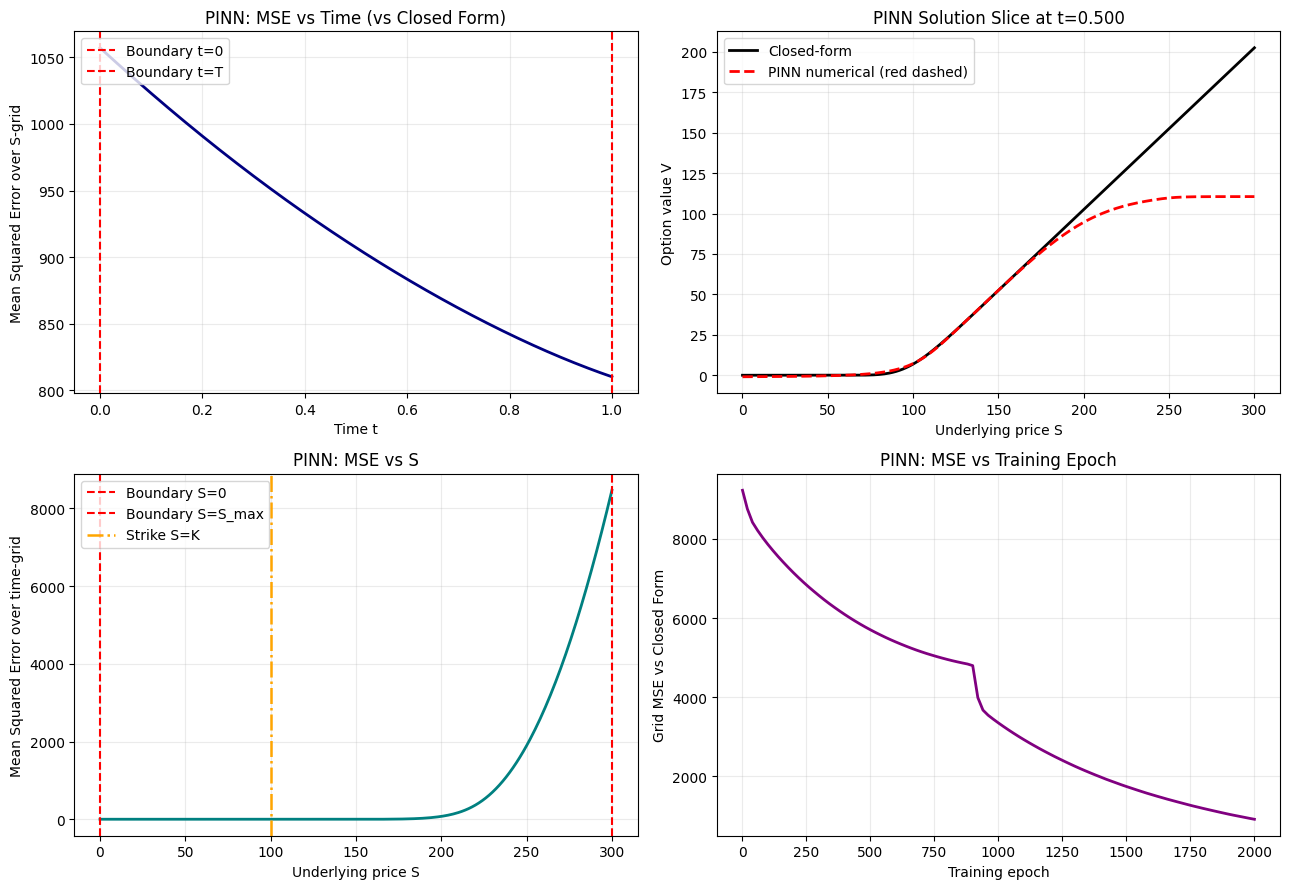

PINN final grid MSE: 9.1589e+02
PINN MSE at t=0: 1.0573e+03


In [6]:
# PINN baseline for Black-Scholes call
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

try:
    import torch
    import torch.nn as nn
except ImportError as e:
    raise ImportError('PyTorch is required for PINN. Install with: pip install torch') from e

torch.manual_seed(42)
np.random.seed(42)

# Parameters
K = 100.0
r = 0.05
sigma = 0.2
T = 1.0
S_min = 0.0
S_max = 300.0

# Evaluation grid (same style as other methods)
Ns = 300
Nt = 300
S_grid = np.linspace(max(S_min, 1e-6), S_max, Ns + 1)
t_grid = np.linspace(0.0, T, Nt + 1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Normalization helpers to [0,1]
def norm_S(S):
    return (S - S_min) / (S_max - S_min + 1e-12)

def norm_t(t):
    return t / (T + 1e-12)

class PINN(nn.Module):
    def __init__(self, width=64, depth=4):
        super().__init__()
        layers = [nn.Linear(2, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, S, t):
        x = torch.cat([norm_S(S), norm_t(t)], dim=1)
        return self.net(x)

model = PINN().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

# Collocation and boundary sample sizes
Nf = 4000
Nb = 800
Ntau = 800
epochs = 2000

def sample_uniform(n, low, high):
    return low + (high - low) * torch.rand(n, 1, device=device)

def bs_call(Sv, tv, K, r, sigma, T):
    tau = T - tv
    Sv = np.asarray(Sv, dtype=float)
    if np.isscalar(tv):
        if tau <= 1e-12:
            return np.maximum(Sv - K, 0.0)
        s = np.maximum(Sv, 1e-300)
        st = np.sqrt(tau)
        d1 = (np.log(s / K) + (r + 0.5 * sigma**2) * tau) / (sigma * st)
        d2 = d1 - sigma * st
        return s * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)
    raise ValueError('tv should be scalar')

def mse_against_closed_form():
    model.eval()
    with torch.no_grad():
        S_eval, t_eval = np.meshgrid(S_grid, t_grid)
        S_t = torch.tensor(S_eval.reshape(-1,1), dtype=torch.float32, device=device)
        t_t = torch.tensor(t_eval.reshape(-1,1), dtype=torch.float32, device=device)
        V_pred = model(S_t, t_t).cpu().numpy().reshape(Nt + 1, Ns + 1)
    V_exact = np.zeros_like(V_pred)
    for n in range(Nt + 1):
        V_exact[n, :] = bs_call(S_grid, t_grid[n], K, r, sigma, T)
    return np.mean((V_pred - V_exact) ** 2), V_pred, V_exact

epoch_hist = []
train_mse_hist = []

for ep in range(1, epochs + 1):
    model.train()
    opt.zero_grad()

    # Interior residual points
    S_f = sample_uniform(Nf, max(S_min, 1e-6), S_max).requires_grad_(True)
    t_f = sample_uniform(Nf, 0.0, T).requires_grad_(True)

    V_f = model(S_f, t_f)
    V_t = torch.autograd.grad(V_f, t_f, grad_outputs=torch.ones_like(V_f), create_graph=True)[0]
    V_S = torch.autograd.grad(V_f, S_f, grad_outputs=torch.ones_like(V_f), create_graph=True)[0]
    V_SS = torch.autograd.grad(V_S, S_f, grad_outputs=torch.ones_like(V_S), create_graph=True)[0]

    pde = V_t + 0.5 * sigma**2 * S_f**2 * V_SS + r * S_f * V_S - r * V_f
    loss_pde = torch.mean(pde**2)

    # Terminal condition t=T
    S_tau = sample_uniform(Ntau, max(S_min, 1e-6), S_max)
    t_tau = torch.full_like(S_tau, T)
    V_tau = model(S_tau, t_tau)
    payoff = torch.clamp(S_tau - K, min=0.0)
    loss_tau = torch.mean((V_tau - payoff)**2)

    # Boundary S=0
    t_b0 = sample_uniform(Nb, 0.0, T)
    S_b0 = torch.full_like(t_b0, max(S_min, 1e-6))
    V_b0 = model(S_b0, t_b0)
    bc0 = torch.zeros_like(V_b0)
    loss_b0 = torch.mean((V_b0 - bc0)**2)

    # Boundary S=S_max
    t_b1 = sample_uniform(Nb, 0.0, T)
    S_b1 = torch.full_like(t_b1, S_max)
    V_b1 = model(S_b1, t_b1)
    bc1 = S_b1 - K * torch.exp(-r * (T - t_b1))
    loss_b1 = torch.mean((V_b1 - bc1)**2)

    loss = loss_pde + 5.0 * loss_tau + loss_b0 + loss_b1
    loss.backward()
    opt.step()

    if ep % 20 == 0 or ep == 1 or ep == epochs:
        mse_ep, _, _ = mse_against_closed_form()
        epoch_hist.append(ep)
        train_mse_hist.append(mse_ep)

# Final evaluation on full grid
final_mse, V_pinn, V_exact = mse_against_closed_form()
sq_err = (V_pinn - V_exact) ** 2
mse_t = np.mean(sq_err, axis=1)
mse_s = np.mean(sq_err, axis=0)

n_mid = Nt // 2

fig, ax = plt.subplots(2, 2, figsize=(13, 9))

ax[0, 0].plot(t_grid, mse_t, color='navy', lw=2)
ax[0, 0].set_title('PINN: MSE vs Time (vs Closed Form)')
ax[0, 0].set_xlabel('Time t')
ax[0, 0].set_ylabel('Mean Squared Error over S-grid')
ax[0, 0].axvline(0.0, color='red', ls='--', lw=1.5, label='Boundary t=0')
ax[0, 0].axvline(T, color='red', ls='--', lw=1.5, label='Boundary t=T')
ax[0, 0].legend(loc='upper left')
ax[0, 0].grid(alpha=0.25)

ax[0, 1].plot(S_grid, V_exact[n_mid, :], color='black', lw=2, label='Closed-form')
ax[0, 1].plot(S_grid, V_pinn[n_mid, :], 'r--', lw=2, label='PINN numerical (red dashed)')
ax[0, 1].set_title(f'PINN Solution Slice at t={t_grid[n_mid]:.3f}')
ax[0, 1].set_xlabel('Underlying price S')
ax[0, 1].set_ylabel('Option value V')
ax[0, 1].legend()
ax[0, 1].grid(alpha=0.25)

ax[1, 0].plot(S_grid, mse_s, color='teal', lw=2)
ax[1, 0].set_title('PINN: MSE vs S')
ax[1, 0].set_xlabel('Underlying price S')
ax[1, 0].set_ylabel('Mean Squared Error over time-grid')
ax[1, 0].axvline(S_min, color='red', ls='--', lw=1.5, label='Boundary S=0')
ax[1, 0].axvline(S_max, color='red', ls='--', lw=1.5, label='Boundary S=S_max')
ax[1, 0].axvline(K, color='orange', ls='-.', lw=1.8, label='Strike S=K')
ax[1, 0].legend(loc='upper left')
ax[1, 0].grid(alpha=0.25)

ax[1, 1].plot(epoch_hist, train_mse_hist, color='purple', lw=2)
ax[1, 1].set_title('PINN: MSE vs Training Epoch')
ax[1, 1].set_xlabel('Training epoch')
ax[1, 1].set_ylabel('Grid MSE vs Closed Form')
ax[1, 1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f'PINN final grid MSE: {final_mse:.4e}')
print(f'PINN MSE at t=0: {mse_t[0]:.4e}')


Under this setup, PINN is less accurate than FD/FE/Fourier. This is not surprising for this setup.

- FD and FE solve a fixed math system directly at each step, so they are usually very stable for this problem.
- PINN has to learn the whole surface by training, which is harder and can miss important shape details.
- The option curve has a sharp bend near the strike and grows quickly for large $S$; PINN often fits these parts poorly unless tuned carefully.
- If training points are spread evenly, the model may not pay enough attention to difficult areas (near maturity, near strike, and at large $S$).

PINN can work, but it usually needs more tuning than FD/FE for Black-Scholes. For this benchmark, traditional PDE solvers are the stronger baseline.


## PINN (Paper-Style) Reproduction Cell: What Is Different and Why It Can Improve

This cell is a **new PINN variant** that is closer to the original PINN training style from Raissi et al.
It does **not** replace the previous PINN cell.

### What is changed vs the previous PINN cell
1. **Fixed collocation sets** (interior / terminal / boundaries):
   - Previous cell resampled points every epoch.
   - This cell keeps one fixed dataset for training (closer to full-batch training setups).
2. **Two-stage optimizer**:
   - Stage A: Adam warm-up for rough fitting.
   - Stage B: full-batch L-BFGS refinement to reduce residual and boundary mismatch more sharply.
3. **Paper-style network details**:
   - Tanh MLP with Xavier initialization.
   - Full-batch objective with PDE + terminal + boundary terms.

### Why these changes can improve approximation
- **Less optimizer noise**: fixed points remove randomness from changing batches, so optimization target is stable.
- **Better final refinement**: L-BFGS can converge faster near a good basin than Adam alone for smooth full-batch objectives.
- **Better joint satisfaction**: quasi-Newton updates often reduce PDE residual and boundary errors together more effectively.

### How this is still different from FD/FE/Fourier
- FD/FE/Fourier solve structured numerical systems directly on grids/bases; they are usually stronger baselines for this PDE.
- PINN is a global function fit with soft constraints, so it is more sensitive to loss weights, sampling, and optimizer settings.
- Even with this improved setup, PINN may still underperform near the payoff kink ($S=K$, $t\approx T$) or far-tail boundary unless tuned further.


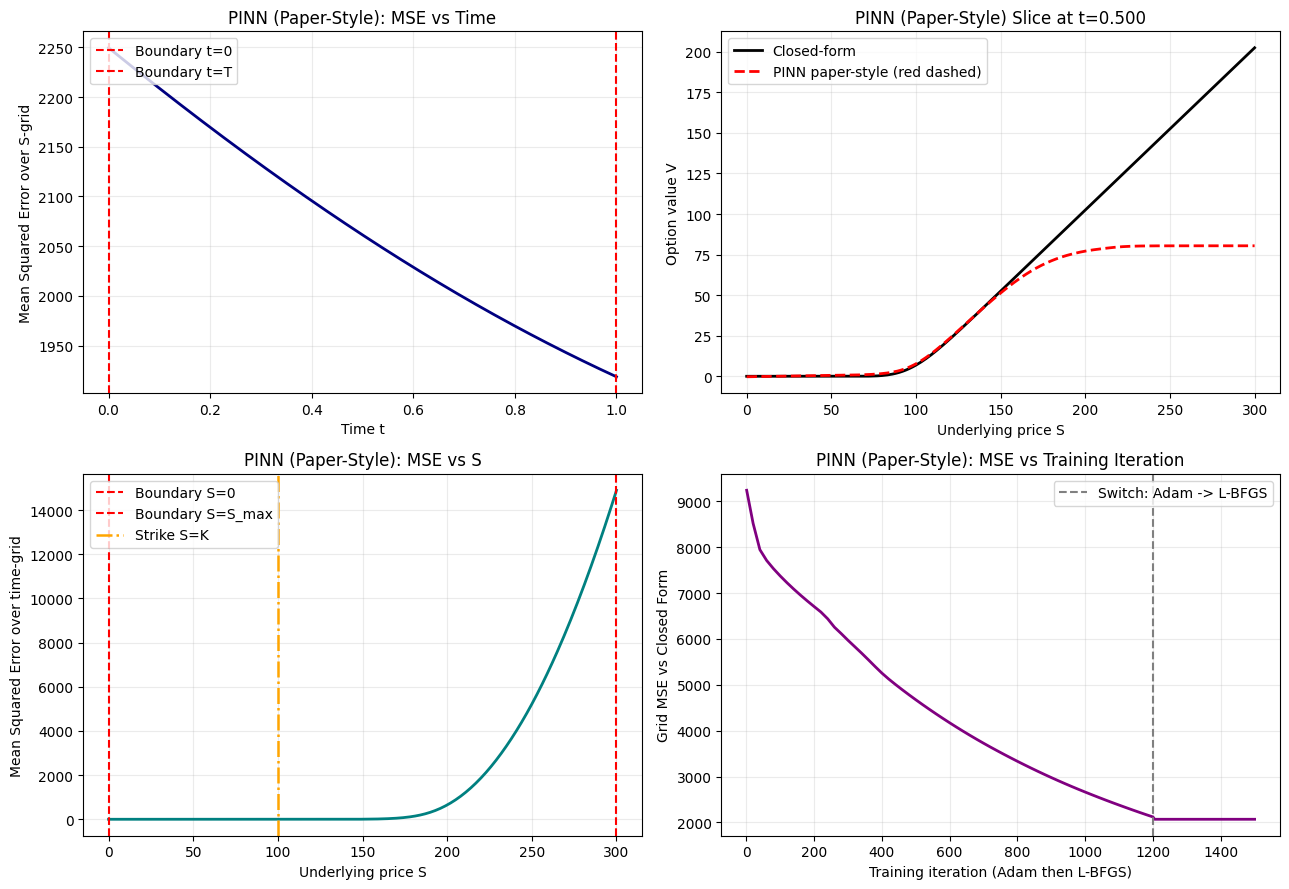

PINN (paper-style) final grid MSE: 2.0690e+03


In [7]:
# PINN (paper-style): fixed collocation + Adam warm-up + L-BFGS
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

try:
    import torch
    import torch.nn as nn
except ImportError as e:
    raise ImportError('PyTorch is required. Install with: pip install torch') from e

torch.manual_seed(123)
np.random.seed(123)

# Parameters
K = 100.0
r = 0.05
sigma = 0.2
T = 1.0
S_min = 0.0
S_max = 300.0

# Evaluation grid (same format as other sections)
Ns = 300
Nt = 300
S_grid = np.linspace(max(S_min, 1e-6), S_max, Ns + 1)
t_grid = np.linspace(0.0, T, Nt + 1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def norm_S(S):
    return (S - S_min) / (S_max - S_min + 1e-12)

def norm_t(t):
    return t / (T + 1e-12)

def lhs_1d(n, low, high):
    # Simple Latin Hypercube in 1D
    u = (np.arange(n) + np.random.rand(n)) / n
    np.random.shuffle(u)
    return (low + (high - low) * u).reshape(-1, 1)

class PINN(nn.Module):
    def __init__(self, width=64, depth=4):
        super().__init__()
        layers = [nn.Linear(2, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)

    def forward(self, S, t):
        x = torch.cat([norm_S(S), norm_t(t)], dim=1)
        return self.net(x)

model = PINN().to(device)

# Fixed collocation datasets (paper-style full-batch flavor)
Nf = 5000
Nb = 1000
Ntau = 1000

S_f_np = lhs_1d(Nf, max(S_min, 1e-6), S_max)
t_f_np = lhs_1d(Nf, 0.0, T)

S_tau_np = lhs_1d(Ntau, max(S_min, 1e-6), S_max)
t_tau_np = np.full((Ntau, 1), T)

t_b0_np = lhs_1d(Nb, 0.0, T)
S_b0_np = np.full((Nb, 1), max(S_min, 1e-6))

t_b1_np = lhs_1d(Nb, 0.0, T)
S_b1_np = np.full((Nb, 1), S_max)

S_f_base = torch.tensor(S_f_np, dtype=torch.float32, device=device)
t_f_base = torch.tensor(t_f_np, dtype=torch.float32, device=device)

S_tau = torch.tensor(S_tau_np, dtype=torch.float32, device=device)
t_tau = torch.tensor(t_tau_np, dtype=torch.float32, device=device)

S_b0 = torch.tensor(S_b0_np, dtype=torch.float32, device=device)
t_b0 = torch.tensor(t_b0_np, dtype=torch.float32, device=device)

S_b1 = torch.tensor(S_b1_np, dtype=torch.float32, device=device)
t_b1 = torch.tensor(t_b1_np, dtype=torch.float32, device=device)

def bs_call(Sv, tv, K, r, sigma, T):
    tau = T - tv
    Sv = np.asarray(Sv, dtype=float)
    if np.isscalar(tv):
        if tau <= 1e-12:
            return np.maximum(Sv - K, 0.0)
        s = np.maximum(Sv, 1e-300)
        st = np.sqrt(tau)
        d1 = (np.log(s / K) + (r + 0.5 * sigma**2) * tau) / (sigma * st)
        d2 = d1 - sigma * st
        return s * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)
    raise ValueError('tv should be scalar')

def eval_grid_mse():
    model.eval()
    with torch.no_grad():
        S_eval, t_eval = np.meshgrid(S_grid, t_grid)
        S_t = torch.tensor(S_eval.reshape(-1, 1), dtype=torch.float32, device=device)
        t_t = torch.tensor(t_eval.reshape(-1, 1), dtype=torch.float32, device=device)
        V_pred = model(S_t, t_t).cpu().numpy().reshape(Nt + 1, Ns + 1)
    V_exact = np.zeros_like(V_pred)
    for n in range(Nt + 1):
        V_exact[n, :] = bs_call(S_grid, t_grid[n], K, r, sigma, T)
    mse = np.mean((V_pred - V_exact) ** 2)
    return mse, V_pred, V_exact

# Loss weights (same form as previous cell; can be tuned)
lam_f, lam_tau, lam_b0, lam_b1 = 1.0, 5.0, 1.0, 1.0

def compute_loss():
    # Need fresh requires_grad tensors for higher-order derivatives each closure call
    S_f = S_f_base.clone().detach().requires_grad_(True)
    t_f = t_f_base.clone().detach().requires_grad_(True)

    V_f = model(S_f, t_f)
    V_t = torch.autograd.grad(V_f, t_f, grad_outputs=torch.ones_like(V_f), create_graph=True)[0]
    V_S = torch.autograd.grad(V_f, S_f, grad_outputs=torch.ones_like(V_f), create_graph=True)[0]
    V_SS = torch.autograd.grad(V_S, S_f, grad_outputs=torch.ones_like(V_S), create_graph=True)[0]

    pde = V_t + 0.5 * sigma**2 * S_f**2 * V_SS + r * S_f * V_S - r * V_f
    loss_f = torch.mean(pde ** 2)

    V_tau = model(S_tau, t_tau)
    payoff = torch.clamp(S_tau - K, min=0.0)
    loss_tau = torch.mean((V_tau - payoff) ** 2)

    V0 = model(S_b0, t_b0)
    loss_b0 = torch.mean(V0 ** 2)

    Vmax = model(S_b1, t_b1)
    target_max = S_b1 - K * torch.exp(-r * (T - t_b1))
    loss_b1 = torch.mean((Vmax - target_max) ** 2)

    total = lam_f * loss_f + lam_tau * loss_tau + lam_b0 * loss_b0 + lam_b1 * loss_b1
    return total

# Stage A: Adam warm-up
adam_epochs = 1200
opt_adam = torch.optim.Adam(model.parameters(), lr=1e-3)

train_iter = []
train_mse = []
iter_count = 0

for ep in range(1, adam_epochs + 1):
    model.train()
    opt_adam.zero_grad()
    loss = compute_loss()
    loss.backward()
    opt_adam.step()

    iter_count += 1
    if ep % 20 == 0 or ep == 1 or ep == adam_epochs:
        mse_ep, _, _ = eval_grid_mse()
        train_iter.append(iter_count)
        train_mse.append(mse_ep)

# Stage B: full-batch L-BFGS refinement
lbfgs_steps = 300
opt_lbfgs = torch.optim.LBFGS(model.parameters(), lr=1.0, max_iter=1, history_size=50, line_search_fn='strong_wolfe')

for k in range(lbfgs_steps):
    def closure():
        opt_lbfgs.zero_grad()
        loss = compute_loss()
        loss.backward()
        return loss

    opt_lbfgs.step(closure)
    iter_count += 1
    if (k + 1) % 5 == 0 or (k + 1) == lbfgs_steps:
        mse_ep, _, _ = eval_grid_mse()
        train_iter.append(iter_count)
        train_mse.append(mse_ep)

# Final evaluation and diagnostics
final_mse, V_pinn2, V_exact2 = eval_grid_mse()
sq_err = (V_pinn2 - V_exact2) ** 2
mse_t = np.mean(sq_err, axis=1)
mse_s = np.mean(sq_err, axis=0)
n_mid = Nt // 2

fig, ax = plt.subplots(2, 2, figsize=(13, 9))

ax[0, 0].plot(t_grid, mse_t, color='navy', lw=2)
ax[0, 0].set_title('PINN (Paper-Style): MSE vs Time')
ax[0, 0].set_xlabel('Time t')
ax[0, 0].set_ylabel('Mean Squared Error over S-grid')
ax[0, 0].axvline(0.0, color='red', ls='--', lw=1.5, label='Boundary t=0')
ax[0, 0].axvline(T, color='red', ls='--', lw=1.5, label='Boundary t=T')
ax[0, 0].legend(loc='upper left')
ax[0, 0].grid(alpha=0.25)

ax[0, 1].plot(S_grid, V_exact2[n_mid, :], color='black', lw=2, label='Closed-form')
ax[0, 1].plot(S_grid, V_pinn2[n_mid, :], 'r--', lw=2, label='PINN paper-style (red dashed)')
ax[0, 1].set_title(f'PINN (Paper-Style) Slice at t={t_grid[n_mid]:.3f}')
ax[0, 1].set_xlabel('Underlying price S')
ax[0, 1].set_ylabel('Option value V')
ax[0, 1].legend()
ax[0, 1].grid(alpha=0.25)

ax[1, 0].plot(S_grid, mse_s, color='teal', lw=2)
ax[1, 0].set_title('PINN (Paper-Style): MSE vs S')
ax[1, 0].set_xlabel('Underlying price S')
ax[1, 0].set_ylabel('Mean Squared Error over time-grid')
ax[1, 0].axvline(S_min, color='red', ls='--', lw=1.5, label='Boundary S=0')
ax[1, 0].axvline(S_max, color='red', ls='--', lw=1.5, label='Boundary S=S_max')
ax[1, 0].axvline(K, color='orange', ls='-.', lw=1.8, label='Strike S=K')
ax[1, 0].legend(loc='upper left')
ax[1, 0].grid(alpha=0.25)

ax[1, 1].plot(train_iter, train_mse, color='purple', lw=2)
ax[1, 1].set_title('PINN (Paper-Style): MSE vs Training Iteration')
ax[1, 1].set_xlabel('Training iteration (Adam then L-BFGS)')
ax[1, 1].set_ylabel('Grid MSE vs Closed Form')
ax[1, 1].axvline(adam_epochs, color='gray', ls='--', lw=1.5, label='Switch: Adam -> L-BFGS')
ax[1, 1].legend(loc='upper right')
ax[1, 1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f'PINN (paper-style) final grid MSE: {final_mse:.4e}')
